In [1]:
from flask import Flask, request, render_template, jsonify
import pandas as pd
import numpy as np
import random
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestNeighbors
from threading import Thread
app = Flask(__name__)

In [2]:
# Load dataset
df = pd.read_csv('Zomato_reduced.csv')
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,...,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city),liked_food_from_review,menus_combined,location_latitude,location_longitude
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,080 42297555\n+91 9743772233,Banashankari,Casual Dining,...,"North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari,"['fried rice', 'soya chaap', 'kulcha', 'rice',...","['pasta,', 'lunch', 'buffet,', 'masala', 'papa...",12.915382,77.573638
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,080 41714161,Banashankari,Casual Dining,...,"Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari,"['chicken', 'fried rice', 'chicken biryan', 'c...","['momos,', 'lunch', 'buffet,', 'chocolate', 'n...",12.915382,77.573638
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,+91 9663487993,Banashankari,"Cafe, Casual Dining",...,"Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari,"['veggies', 'egg', 'pasta', 'cake', 'chocolate...","['churros,', 'cannelloni,', 'minestrone', 'sou...",12.915382,77.573638
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,+91 9620009302,Banashankari,Quick Bites,...,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari,"['pulka', 'apple', 'rice with sambar', 'dosa',...","['masala', 'dosa', 'pulka', 'apple', 'rice wit...",12.915382,77.573638
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,+91 8026612447\n+91 9901210005,Basavanagudi,Casual Dining,...,"North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari,"['roti', 'noodles', 'kulcha', 'pav bhaji', 'pa...","['panipuri,', 'gol', 'gappe', 'roti', 'noodles...",12.941726,77.575502


In [3]:
# Data Preprocessing
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')
df.dropna(subset=['rate'], inplace=True)
df = df.groupby(['name', 'location', 'cuisines', 'url']).agg({'rate': 'mean', 'votes': 'sum'}).reset_index()

In [4]:
# Encode cuisines for ML
label_encoder = LabelEncoder()
df['cuisine_encoded'] = label_encoder.fit_transform(df['cuisines'])

In [5]:
# Train KNN Model
knn = NearestNeighbors(n_neighbors=5, metric='euclidean')
knn.fit(df[['cuisine_encoded', 'rate', 'votes']])

NearestNeighbors(metric='euclidean')

In [6]:
def recommend_restaurant(preferred_cuisine, top_n=5):
    print("Requested cuisine:", preferred_cuisine)

    if preferred_cuisine not in label_encoder.classes_:
        print("Cuisine not found!")
        return [{"name": "No recommendations available", "location": "-", "rate": "-", "url": "#"}]

    cuisine_code = label_encoder.transform([preferred_cuisine])[0]
    
    # Create DataFrame instead of list to match training input
    query_point = pd.DataFrame([{
        'cuisine_encoded': cuisine_code,
        'rate': df['rate'].mean(),
        'votes': df['votes'].mean()
    }])

    distances, indices = knn.kneighbors(query_point)

    recommendations = df.iloc[indices[0]][['name', 'location', 'rate', 'url']].to_dict(orient='records')
    
    print("Recommendations found:", recommendations)
    return recommendations if recommendations else [{"name": "No recommendations available", "location": "-", "rate": "-", "url": "#"}]


In [7]:


@app.route('/')
def home():
    return render_template('index.html')

@app.route('/get_cuisines', methods=['GET'])
def get_cuisines():
    cuisines = sorted(df['cuisines'].unique().tolist())
    return jsonify(cuisines)

@app.route('/recommend', methods=['POST'])
def recommend():
    preferred_cuisine = request.form['cuisine']
    recommendations = recommend_restaurant(preferred_cuisine)
    return jsonify(recommendations)


In [8]:
def run_app():
    app.run(port=5000, debug=False, use_reloader=False)

thread = Thread(target=run_app)
thread.start()


 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [26/May/2026 20:41:52] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [26/May/2026 20:41:52] "GET /get_cuisines HTTP/1.1" 200 -
127.0.0.1 - - [26/May/2026 20:41:53] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [26/May/2026 20:41:57] "POST /recommend HTTP/1.1" 200 -


Requested cuisine: Burger
Recommendations found: [{'name': 'KFC', 'location': 'ITPL Main Road, Whitefield', 'rate': 2.8, 'url': 'https://www.zomato.com/bangalore/kfc-3-whitefield?context=eyJzZSI6eyJlIjpbIjE4NzE4Njg5IiwiMTg3NjY1ODkiLCIxODk0NzQzMyIsIjU3NzE3Iiw1MzQ4MSwiMTg1OTQ1NjEiLCIxODI0NjUxNiIsIjE4ODIyNDYyIiwiMTgyNTQ1OTciLCIxODM5ODM5MyIsIjE4NTQ5NTA3IiwiMTg0NTA4ODUiLCIxODc0NTYwMCIsIjE4NDcwNzg0IiwiMTg1ODAxNzQiLCIxODc2NTM4MiIsIjE4Nzk3NjQ3IiwiMTgyMjE1NTkiXSwidCI6IkRlbGl2ZXJ5IFJlc3RhdXJhbnRzIGluIEJyb29rZWZpZWxkIn19'}, {'name': "McDonald's", 'location': 'Bannerghatta Road', 'rate': 4.0, 'url': 'https://www.zomato.com/bangalore/mcdonalds-1-bannerghatta-road?context=eyJzZSI6eyJlIjpbIjE4NDU4Mzk4IiwiNTg4MzMiLCI1MjgzMSIsIjE4Nzk1NTQ3Iiw1MTg1MCwiMTg3Nzk2NTEiLCIxODYxNTg0MyIsIjE4NTUxOTQyIiwiMTg2NzM0MjMiLCIxODkwNDU3MCIsIjUxMDcxIiwiMTgyMzI2NTgiLCIxODU0NDIxOCIsIjE4MjgwNzE3IiwiMTg0Njg4MzUiLCI1MDM5NiIsIjUyNjg1IiwiMTg2NTY2MjEiLCIxODU4Mjc3MiIsIjUzMzU4Il0sInQiOiJEZWxpdmVyeSBSZXN0YXVyYW50cyBpbiBCYW5uZXJnaGF0d

127.0.0.1 - - [26/May/2026 20:42:05] "POST /recommend HTTP/1.1" 200 -


Requested cuisine: American
Recommendations found: [{'name': 'The Barn - Bar & Kitchen', 'location': 'Brigade Road', 'rate': 4.2, 'url': 'https://www.zomato.com/bangalore/the-barn-bar-kitchen-brigade-road-bangalore?context=eyJzZSI6eyJlIjpbIjE4Mjg3NDMzIiwiMTg4NzEyNDYiLCI1MzU2NiIsIjUwNDczIiwxODczNDA5NCwiMTg4NjY4NjUiLCIxODcwNTA3MyIsIjUwNTkwIiwiNTEyOTMiLCI1NjIwOCIsIjU3MDMyIiwiNTA0NTgiLCI1MTY1NSIsIjE4ODExMDE5IiwiNTQ2NTUiLCIxODM5MTYwNyIsIjUyMTI5IiwiNTA0MzMiLCI1MTAwNyIsIjE4NzUyMjcwIiwiMTg0NTUwNjYiXSwidCI6IkRpbmUtT3V0IFJlc3RhdXJhbnRzIGluIEJyaWdhZGUgUm9hZCJ9fQ=='}, {'name': 'S.W.A.T Food Truck', 'location': 'East Bangalore', 'rate': 3.7, 'url': 'https://www.zomato.com/s-w-a-t-food-truck-food-truck?context=eyJzZSI6eyJlIjpbIjU1MzUzIiwiMTg0OTM4OTMiLCIxODY3NTYwNSIsIjUwMjg3IiwxODA0ODIyNCwiMTg0MzA3NjYiLCIxODY2NjEyOSIsIjE4NjMyMjU4IiwiMTg2ODAxMDciLCIxODY2MDc2MSIsIjE4OTQ2MzE3IiwiMTg0MzQ1NzEiLCI1MDM1MyIsIjE4Mjk4MjMxIiwiMTg4NTY5MTciXSwidCI6IkRlbGl2ZXJ5IFJlc3RhdXJhbnRzIGluIEluZGlyYW5hZ2FyIn19'}, {'name': '

127.0.0.1 - - [26/May/2026 20:42:10] "POST /recommend HTTP/1.1" 200 -


Requested cuisine: Chinese
Recommendations found: [{'name': 'Chungs Pavilion', 'location': 'Indiranagar', 'rate': 3.9, 'url': 'https://www.zomato.com/bangalore/chungs-pavilion-indiranagar?context=eyJzZSI6eyJlIjpbIjE4NzQ5MTQyIiwiNTUzNTMiLCIxODQ5Mzg5MyIsIjE4Njc1NjA1Iiw1MDI4NywiMTgwNDgyMjQiLCIxODQzMDc2NiIsIjE4NjY2MTI5IiwiMTg2MzIyNTgiLCIxODY4MDEwNyIsIjE4NjYwNzYxIiwiMTg5NDYzMTciLCIxODQzNDU3MSIsIjUwMzUzIiwiMTgyOTgyMzEiLCIxODg1NjkxNyJdLCJ0IjoiRGVsaXZlcnkgUmVzdGF1cmFudHMgaW4gSW5kaXJhbmFnYXIifX0='}, {'name': "Dragon's Kitchen", 'location': 'HSR', 'rate': 3.1, 'url': 'https://www.zomato.com/bangalore/dragons-kitchen-1-hsr?context=eyJzZSI6eyJlIjpbIjE4ODYyNzc1IiwiMTgyMTY2NzgiLCIxODcwNDIyMCIsIjE4NDg5MTE3Iiw1Mzk5NiwiNTEwNDEiLCIxODcwNjA4MCIsIjUxMjU1IiwiMTgzODczOTMiLCIxODc2NTQ2NCIsIjE4NzQ4NjA3IiwiMTg5MDE4ODAiLCIxODkyOTA5NyIsIjE4NjU4Nzk0IiwiMTgwODk2OTciLCIxODY2MDcyNiIsIjYwMDkwIiwiMTgyMDgzNTIiXSwidCI6IkRlbGl2ZXJ5IFJlc3RhdXJhbnRzIGluIEJUTSJ9fQ=='}, {'name': "Chung's Chinese Corner", 'location': 'Kalyan N

127.0.0.1 - - [26/May/2026 20:42:17] "POST /recommend HTTP/1.1" 200 -


Requested cuisine: Asian
Recommendations found: [{'name': 'InAzia - Sheraton Grand Bengaluru Whitefield Hotel &...', 'location': 'Whitefield', 'rate': 4.3, 'url': 'https://www.zomato.com/bangalore/inazia-sheraton-grand-bengaluru-whitefield-hotel-convention-centre-whitefield-bangalore?context=eyJzZSI6eyJlIjpbIjE4ODA2NDM2IiwiMTg0MTY1MzQiLCIxODI5MDA2MSIsIjE4NTEyNzkyIiwxODY2MTA5MCwiMTg0ODkxMjgiLCI1MzEyMiIsIjUwNjY0IiwiNTg0ODgiLCIxODg1MTIwNSIsIjU0MTUzIiwiMTg2MDgxOTUiLCIxODU0NTk5MCIsIjE4NjEyOTE5IiwiMTg1MzY0NjQiLCI1NTIyNiIsIjU2NzY3IiwiMTgyMzc5MzgiLCIxODQ1NDM3MiIsIjUyMDA0IiwiMTg3MzM1NzkiLCIxODUwMzcyNyIsIjE4NTM2NzI1Il0sInQiOiJEaW5lLU91dCBSZXN0YXVyYW50cyBpbiBXaGl0ZWZpZWxkIn19'}, {'name': 'Ging - Royal Orchid Central', 'location': 'MG Road', 'rate': 4.3, 'url': 'https://www.zomato.com/bangalore/ging-royal-orchid-central-mg-road?context=eyJzZSI6eyJlIjpbIjU5MDI0IiwiMTgyMTY2OTAiLCIxODkwMjQ0NyIsIjE4Nzc1ODI1IiwxODU2NjcxMywiMTg2NDkzMTAiLCI1NjQ0NSIsIjE4NjI4MjA0IiwiMTg3MTEzMDMiLCIxODE2Mzg0NyIsIjE4NzYzMjYw

C:\Users\Anirudh Sharma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
C:\Users\Anirudh Sharma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


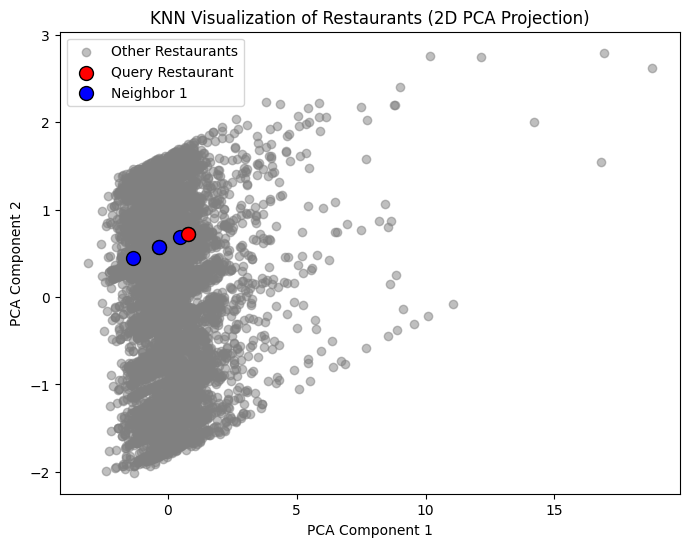

In [9]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Select a random point to use as a query
random_index = random.randint(0, len(df) - 1)
query_point = df[['cuisine_encoded', 'rate', 'votes']].iloc[random_index].values.reshape(1, -1)

# Standardize the features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[['cuisine_encoded', 'rate', 'votes']])

# Apply PCA to reduce the dimensions to 2D
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# Get the nearest neighbors of the query point
distances, indices = knn.kneighbors(query_point)

# Get the 2D coordinates of the query point and its nearest neighbors
query_2d = pca.transform(scaler.transform(query_point))[0]
neighbors_2d = pca_data[indices[0]]

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], color='gray', label='Other Restaurants', alpha=0.5)
plt.scatter(query_2d[0], query_2d[1], color='red', label='Query Restaurant', s=100, edgecolor='black', zorder=5)

# Plot nearest neighbors
for i, neighbor in enumerate(neighbors_2d):
    plt.scatter(neighbor[0], neighbor[1], color='blue', s=100, edgecolor='black', label=f'Neighbor {i+1}' if i == 0 else "")

plt.title("KNN Visualization of Restaurants (2D PCA Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()


In [10]:
import random
import numpy as np
from sklearn.metrics import mean_squared_error, f1_score
from math import sqrt
random.seed(42)
sample_cuisines = random.sample(df['cuisines'].unique().tolist(), 50)
precision_scores = []
recall_scores = []
rmse_scores = []
f1_scores = []
for cuisine in sample_cuisines:
    recommendations = recommend_restaurant(cuisine, top_n=5)
    # Filter dataset for this cuisine
    relevant_df = df[df['cuisines'] == cuisine]
    # Relevant items in dataset
    all_relevant = relevant_df[relevant_df['rate'] >= 4.0].shape[0]
    if all_relevant == 0:
        continue  # Skip cuisines with no relevant entries
    # Recommendations
    relevant_recs = [rec for rec in recommendations if rec['rate'] >= 4.0]
    # Precision@5
    precision = len(relevant_recs) / 5
    precision_scores.append(precision)
    # Recall@5 - Ensure recall doesn't exceed 1
    recall = min(len(relevant_recs) / all_relevant, 1)  # Ensure recall doesn't exceed 1
    recall_scores.append(recall)
    # F1 Score
    if precision + recall > 0:
        f1 = 2 * (precision * recall) / (precision + recall)
        f1_scores.append(f1)
    # RMSE
    true_ratings = relevant_df['rate'].head(len(recommendations))
    predicted_ratings = [rec['rate'] for rec in recommendations[:len(true_ratings)]]
    if len(true_ratings) == len(predicted_ratings):
        rmse_scores.append(sqrt(mean_squared_error(true_ratings, predicted_ratings)))
# Final metrics
print("Average Precision@5:", round(np.mean(precision_scores), 3))
print("Average Recall@5:", round(np.mean(recall_scores), 3))
print("Average F1 Score:", round(np.mean(f1_scores), 3))
print("Average RMSE:", round(np.mean(rmse_scores), 3))


Requested cuisine: Cafe, American, Burger, Sandwich, Fast Food
Recommendations found: [{'name': 'Steaming Mugs', 'location': 'Basavanagudi', 'rate': 3.9, 'url': 'https://www.zomato.com/bangalore/steaming-mugs-basavanagudi?context=eyJzZSI6eyJlIjpbIjU0ODA4IiwiMTg1MTE2MzUiLCIxODY5NDk1NCIsIjE4ODgxNzY2IiwxODQzOTY3MCwiNTkwOTAiLCI1OTg1MCIsIjE4NTQwNjM5IiwiNTE0NTgiLCI2MDgzNCIsIjE4NjQzNTM0IiwiMTgyNDQzMTIiLCI1MTQwNyIsIjE4NjUzNTE2IiwiMTgxNTQ4OTQiLCI1NDMyMyIsIjE4OTI5OTE3IiwiNTkyNTEiLCI1NjgwNCIsIjE4ODY3MTIyIiwiNTQzNTIiLCIxODYzMjk3NyJdLCJ0IjoiRGVsaXZlcnkgUmVzdGF1cmFudHMgaW4gQmFuYXNoYW5rYXJpIn19'}, {'name': 'Crafted Plate', 'location': 'JP Nagar', 'rate': 4.2, 'url': 'https://www.zomato.com/bangalore/crafted-plate-jp-nagar?context=eyJzZSI6eyJlIjpbIjE4NzgwNjc3IiwiMTg3MTgzNzAiLCIxODg5Mjk5NSIsIjE4NTIwMzkwIiwxODY1NTMwNCwiMTg1OTQwMDkiLCIxODczNTI5MiIsIjE4NTQ1MDU3IiwiMTg4ODUzMzgiLCIxODYzMTU3NyIsIjU1NDYwIiwiMTg1NTMzNzciLCI2MTQ1NCIsIjU2NjM1IiwiMTg3NTY2MzEiLCIxODYwNDY4OCIsIjE4NjYzNzgyIl0sInQiOiJEZWxpdmVyeSBSZXN

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar plot: Top cuisines
plt.figure(figsize=(10, 6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette="viridis")
plt.title("Top 10 Most Common Cuisines")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")
plt.tight_layout()
plt.show()  # This will display the bar chart

# Histogram: Distribution of restaurant ratings
plt.figure(figsize=(10, 6))
sns.histplot(df["rate"].dropna(), bins=20, kde=True, color="coral")
plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()  # This will display the histogram


NameError: name 'top_cuisines' is not defined

<Figure size 1000x600 with 0 Axes>